In [1]:
import pandas as pd
import numpy as np

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
net = pd.read_parquet("../Data/network/Benign-Monday-no-metadata.parquet")
print(net.shape)
print(net.head())

(458831, 78)
   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         6              4                  2                       0   
1         6              1                  2                       0   
2         6              3                  2                       0   
3         6              1                  2                       0   
4         6            609                  7                       4   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                        12                         0                      6   
1                        12                         0                      6   
2                        12                         0                      6   
3                        12                         0                      6   
4                       484                       414                    233   

   Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length

In [3]:
print(net.columns.tolist())

['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ra

In [5]:
ddos = pd.read_parquet("../Data/network/DDoS-Friday-no-metadata.parquet")

print(ddos["Label"].value_counts())
print(ddos.shape)

Label
DDoS      128014
Benign     93250
Name: count, dtype: int64
(221264, 78)


In [9]:
features = [
    'Protocol',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Fwd Packets Length Total',
    'Bwd Packets Length Total',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Mean',
    'Packet Length Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'RST Flag Count',
    'Avg Packet Size',
    'Active Mean',
    'Idle Mean'
]

In [10]:
X_train = net[features].copy()
print(X_train.head())
print(X_train.shape)

   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         6              4                  2                       0   
1         6              1                  2                       0   
2         6              3                  2                       0   
3         6              1                  2                       0   
4         6            609                  7                       4   

   Fwd Packets Length Total  Bwd Packets Length Total  Flow Bytes/s  \
0                        12                         0  3.000000e+06   
1                        12                         0  1.200000e+07   
2                        12                         0  4.000000e+06   
3                        12                         0  1.200000e+07   
4                       484                       414  1.474548e+06   

   Flow Packets/s  Packet Length Mean  Packet Length Std  SYN Flag Count  \
0    5.000000e+05            6.000000           0.000000  

In [11]:
X_test = ddos[features].copy()
y_test = ddos["Label"]

In [12]:
import numpy as np

X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.15,
    random_state=42
)

model.fit(X_train_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.15
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [15]:
pred = model.predict(X_test_scaled)

In [16]:
import pandas as pd

pred_labels = np.where(pred == -1, "Anomaly", "Normal")

print(pd.Series(pred_labels).value_counts())

Normal     112643
Anomaly    108621
Name: count, dtype: int64


In [18]:
results = pd.DataFrame({
    "True_Label": y_test.values,
    "Prediction": pred_labels
})

print(pd.crosstab(results["True_Label"], results["Prediction"]))

Prediction  Anomaly  Normal
True_Label                 
Benign        27172   66078
DDoS          81449   46565


In [20]:
from sklearn.metrics import classification_report

y_true = np.where(y_test == "DDoS", "Anomaly", "Normal")
print(classification_report(y_true, pred_labels))

              precision    recall  f1-score   support

     Anomaly       0.75      0.64      0.69    128014
      Normal       0.59      0.71      0.64     93250

    accuracy                           0.67    221264
   macro avg       0.67      0.67      0.67    221264
weighted avg       0.68      0.67      0.67    221264



In [21]:
model = IsolationForest(n_estimators=100, contamination=0.10, random_state=42)

In [23]:
import joblib

joblib.dump(model, "../models/isolation_forest_network.pkl")
joblib.dump(scaler, "../models/network_scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [24]:
rf_data = pd.concat([net, ddos], ignore_index=True)

print(rf_data["Label"].value_counts())
print(rf_data.shape)

Label
Benign    552081
DDoS      128014
Name: count, dtype: int64
(680095, 78)


In [25]:
X = rf_data[features].copy()
y = rf_data["Label"].copy()

In [26]:
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

In [27]:
from sklearn.model_selection import train_test_split

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
rf_pred = rf_model.predict(X_test_rf)

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test_rf, rf_pred))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    110416
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00    136019
   macro avg       1.00      1.00      1.00    136019
weighted avg       1.00      1.00      1.00    136019



In [31]:
joblib.dump(rf_model, "../models/random_forest_network.pkl")
print("RF Model Saved")

RF Model Saved


In [32]:
portscan = pd.read_parquet("../Data/network/Portscan-Friday-no-metadata.parquet")
web = pd.read_parquet("../Data/network/WebAttacks-Thursday-no-metadata.parquet")
botnet = pd.read_parquet("../Data/network/Botnet-Friday-no-metadata.parquet")
brute = pd.read_parquet("../Data/network/Bruteforce-Tuesday-no-metadata.parquet")

In [33]:
multi_data = pd.concat(
    [net, ddos, portscan, web, botnet, brute],
    ignore_index=True
)

print(multi_data["Label"].value_counts())
print(multi_data.shape)

Label
Benign                        1378489
DDoS                           128014
FTP-Patator                      5931
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Web Attack � Sql Injection         21
Name: count, dtype: int64
(1521189, 78)


In [34]:
X = multi_data[features].copy()
y = multi_data["Label"].copy()

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
rf_multi = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

rf_multi.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
pred = rf_multi.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

c:\Users\FYP CS-22\Desktop\FYP_AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\FYP CS-22\Desktop\FYP_AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00    275698
                       Bot       0.77      0.66      0.71       288
                      DDoS       1.00      1.00      1.00     25603
               FTP-Patator       0.99      1.00      1.00      1186
                  PortScan       0.91      0.94      0.93       391
               SSH-Patator       0.99      0.92      0.96       644
  Web Attack � Brute Force       0.23      0.20      0.21       294
Web Attack � Sql Injection       0.00      0.00      0.00         4
          Web Attack � XSS       0.12      0.11      0.11       130

                  accuracy                           1.00    304238
                 macro avg       0.67      0.65      0.66    304238
              weighted avg       1.00      1.00      1.00    304238



c:\Users\FYP CS-22\Desktop\FYP_AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [38]:
joblib.dump(rf_multi, "../models/random_forest_multiclass.pkl")
print("Multiclass RF Saved")

Multiclass RF Saved


In [2]:
import joblib
import pandas as pd
import numpy as np

# Load model
rf_multi = joblib.load("../models/random_forest_multiclass.pkl")

In [2]:
net = pd.read_parquet("../Data/network/Benign-Monday-no-metadata.parquet")
ddos = pd.read_parquet("../Data/network/DDoS-Friday-no-metadata.parquet")
portscan = pd.read_parquet("../Data/network/Portscan-Friday-no-metadata.parquet")
web = pd.read_parquet("../Data/network/WebAttacks-Thursday-no-metadata.parquet")
botnet = pd.read_parquet("../Data/network/Botnet-Friday-no-metadata.parquet")
brute = pd.read_parquet("../Data/network/Bruteforce-Tuesday-no-metadata.parquet")

multi_data = pd.concat(
    [net, ddos, portscan, web, botnet, brute],
    ignore_index=True
)

In [3]:
features = [
    'Protocol',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Fwd Packets Length Total',
    'Bwd Packets Length Total',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Mean',
    'Packet Length Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'RST Flag Count',
    'Avg Packet Size',
    'Active Mean',
    'Idle Mean'
]

X = multi_data[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = multi_data["Label"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
pred = rf_multi.predict(X_test)

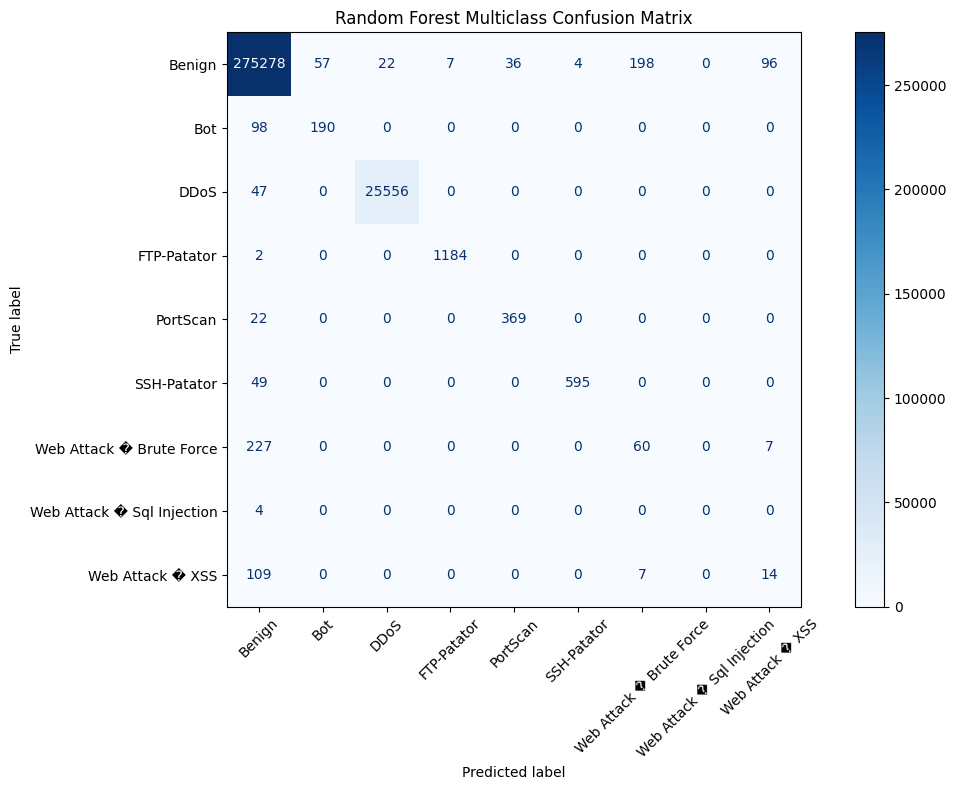

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred, labels=rf_multi.classes_)

fig, ax = plt.subplots(figsize=(12,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_multi.classes_
)

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Random Forest Multiclass Confusion Matrix")
plt.tight_layout()
plt.show()

In [3]:
cloud = pd.read_csv("../Data/cloud/dataset_final_testset_merged.csv")

print(cloud.head())
print(cloud.columns.tolist())
print(cloud.shape)
print(cloud["Label"].value_counts())

         Date          Time  PID  Level           Module Request  \
0  2021-07-05  14:01:15.456  918  ERROR   cinder.service       -   
1  2021-07-05  14:01:25.461  918  ERROR   cinder.service       -   
2  2021-07-05  14:01:35.468  918  ERROR   cinder.service       -   
3  2021-07-05  14:01:45.471  918  ERROR   cinder.service       -   
4  2021-07-05  14:01:55.477  918  ERROR   cinder.service       -   

                                             Message   Label    0    3  
0  Manager for service cinder-volume juju-c202fd-...  cinder  NaN  NaN  
1  Manager for service cinder-volume juju-c202fd-...  cinder  NaN  NaN  
2  Manager for service cinder-volume juju-c202fd-...  cinder  NaN  NaN  
3  Manager for service cinder-volume juju-c202fd-...  cinder  NaN  NaN  
4  Manager for service cinder-volume juju-c202fd-...  cinder  NaN  NaN  
['Date', 'Time', 'PID', 'Level', 'Module', 'Request', 'Message', 'Label', '0', '3']
(36029, 10)
Label
cinder    17965
nova      17851
glance      213
Nam

In [4]:
cloud = cloud.drop(columns=["0", "3"], errors="ignore")

print(cloud.columns)
print(cloud.shape)

Index(['Date', 'Time', 'PID', 'Level', 'Module', 'Request', 'Message',
       'Label'],
      dtype='str')
(36029, 8)


In [5]:
print(cloud["Level"].value_counts())

Level
DEBUG      17717
ERROR      15325
WARNING     2501
INFO         486
Name: count, dtype: int64


In [6]:
cloud["Target"] = cloud["Level"].apply(
    lambda x: "Suspicious" if x in ["ERROR", "WARNING"] else "Normal"
)

print(cloud["Target"].value_counts())

Target
Normal        18203
Suspicious    17826
Name: count, dtype: int64


In [7]:
cloud["Hour"] = pd.to_datetime(cloud["Time"], format="%H:%M:%S.%f").dt.hour

cloud["Message_Length"] = cloud["Message"].astype(str).apply(len)

In [8]:
X = cloud[["PID", "Module", "Label", "Hour", "Message_Length"]].copy()
y = cloud["Target"].copy()

In [9]:
X = pd.get_dummies(X, columns=["Module", "Label"], drop_first=True)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
from sklearn.ensemble import RandomForestClassifier

cloud_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

cloud_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
pred = cloud_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      3641
  Suspicious       1.00      1.00      1.00      3565

    accuracy                           1.00      7206
   macro avg       1.00      1.00      1.00      7206
weighted avg       1.00      1.00      1.00      7206



In [13]:
cloud = cloud.sort_values(["Date","Time"])

split = int(len(cloud)*0.8)

train_df = cloud.iloc[:split]
test_df = cloud.iloc[split:]

In [14]:
train_df["Hour"] = pd.to_datetime(train_df["Time"]).dt.hour
test_df["Hour"] = pd.to_datetime(test_df["Time"]).dt.hour

train_df["Message_Length"] = train_df["Message"].astype(str).apply(len)
test_df["Message_Length"] = test_df["Message"].astype(str).apply(len)

C:\Users\Hamad Ali\AppData\Local\Temp\ipykernel_8112\1169454837.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_df["Hour"] = pd.to_datetime(train_df["Time"]).dt.hour
C:\Users\Hamad Ali\AppData\Local\Temp\ipykernel_8112\1169454837.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_df["Hour"] = pd.to_datetime(test_df["Time"]).dt.hour


In [15]:
X_train = train_df[["PID", "Module", "Label", "Hour", "Message_Length"]].copy()
y_train = train_df["Target"].copy()

X_test = test_df[["PID", "Module", "Label", "Hour", "Message_Length"]].copy()
y_test = test_df["Target"].copy()

In [16]:
X_train = pd.get_dummies(X_train, columns=["Module", "Label"])
X_test = pd.get_dummies(X_test, columns=["Module", "Label"])

In [17]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [18]:
from sklearn.ensemble import RandomForestClassifier

cloud_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

cloud_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
pred = cloud_model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7176
  Suspicious       1.00      1.00      1.00        30

    accuracy                           1.00      7206
   macro avg       1.00      1.00      1.00      7206
weighted avg       1.00      1.00      1.00      7206



In [21]:
import joblib

joblib.dump(cloud_model, "../models/cloud_random_forest.pkl")
print("Cloud model saved")

Cloud model saved


In [22]:
host = pd.read_json("../Data/host/wls_day-01", lines=True, nrows=100000)

print(host.head())
print(host.columns.tolist())
print(host.shape)

      UserName  EventID     LogHost LogonID DomainName ParentProcessName  \
0  Comp607982$     4688  Comp607982   0x3e7  Domain001          services   
1  Comp991643$     4688  Comp991643   0x3e7  Domain001          services   
2  Comp736087$     4688  Comp736087   0x3e7  Domain001          services   
3  Comp093128$     4688  Comp093128   0x3e7  Domain001          services   
4  Comp006850$     4688  Comp006850   0x3e7  Domain001          services   

  ParentProcessID   ProcessName  Time ProcessID  ... AuthenticationPackage  \
0           0x2ac   svchost.exe     1    0x1418  ...                   NaN   
1           0x334  rundll32.exe     1     0xc0c  ...                   NaN   
2           0x2e8   svchost.exe     1    0x2074  ...                   NaN   
3           0x2d4     vssvc.exe     1    0x2200  ...                   NaN   
4           0x278   svchost.exe     1     0x498  ...                   NaN   

  LogonType  Source Destination SubjectUserName SubjectLogonID  \
0       

In [29]:
print(host["EventID"].value_counts().head(15))


EventID
4688    40371
4624    22365
4634    13879
4672    13495
4776     5912
4769     1730
4648     1295
4768      575
4625      371
4800        3
4689        3
4609        1
Name: count, dtype: int64


In [27]:
print(host.isnull().sum())

UserName                     1
EventID                      0
LogHost                      0
LogonID                   8369
DomainName                   1
ParentProcessName        59629
ParentProcessID          59629
ProcessName              49309
Time                         0
ProcessID                49309
LogonTypeDescription     63385
AuthenticationPackage    71352
LogonType                63385
Source                   81115
Destination              98705
SubjectUserName          98696
SubjectLogonID           98694
SubjectDomainName        98696
Status                   91783
ServiceName              98270
FailureReason            99629
dtype: int64


In [30]:
print(host["ProcessName"].value_counts().head(20))

ProcessName
wmiprvse.exe              12315
services.exe               7725
svchost.exe                4172
vssvc.exe                  3688
rundll32.exe               2650
dllhost.exe                2454
searchfilterhost.exe       1871
searchprotocolhost.exe     1778
conhost.exe                1576
Proc746489.exe             1508
Proc551373.exe             1481
taskhost.exe                820
cmd.exe                     748
Proc483132.exe              513
Proc782241.exe              432
cscript.exe                 427
taskeng.exe                 401
Proc250529.exe              312
Proc857443.exe              301
Proc461749.exe              232
Name: count, dtype: int64


In [31]:
host_clean = host.copy()

host_clean["Hour"] = host_clean["Time"] % 24

host_clean["Is_Failed_Logon"] = (host_clean["EventID"] == 4625).astype(int)
host_clean["Is_Process_Create"] = (host_clean["EventID"] == 4688).astype(int)
host_clean["Is_Privilege"] = (host_clean["EventID"] == 4672).astype(int)

host_clean["ProcessName"] = host_clean["ProcessName"].fillna("Unknown")
host_clean["ParentProcessName"] = host_clean["ParentProcessName"].fillna("Unknown")
host_clean["UserName"] = host_clean["UserName"].fillna("Unknown")
host_clean["LogHost"] = host_clean["LogHost"].fillna("Unknown")

In [32]:
X = host_clean[
    [
        "EventID",
        "Hour",
        "Is_Failed_Logon",
        "Is_Process_Create",
        "Is_Privilege"
    ]
].copy()

In [33]:
from sklearn.ensemble import IsolationForest

host_model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

host_model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [34]:
pred = host_model.predict(X)

host_clean["Anomaly"] = pred
print(host_clean["Anomaly"].value_counts())

Anomaly
 1    98190
-1     1810
Name: count, dtype: int64


In [35]:
host_clean[host_clean["Anomaly"] == -1][
    ["EventID", "UserName", "LogHost", "ProcessName", "ParentProcessName", "Time"]
].head(30)

,EventID,UserName,LogHost,ProcessName,ParentProcessName,Time
29879,4625,Comp635369$,Comp635369,Proc746489.exe,Unknown,4
29884,4625,Comp635369$,Comp635369,Proc746489.exe,Unknown,4
29885,4625,Comp635369$,Comp635369,Proc746489.exe,Unknown,4
29886,4625,Comp635369$,Comp635369,Proc746489.exe,Unknown,4
29887,4625,Comp635369$,Comp635369,Proc746489.exe,Unknown,4
30456,4625,AppService,EnterpriseAppServer,Proc813133.exe,Unknown,5
31375,4625,Comp065845$,Comp065845,Proc275807.exe,Unknown,5
31376,4625,Comp065845$,Comp065845,Proc275807.exe,Unknown,5
31377,4625,Comp065845$,Comp065845,Proc275807.exe,Unknown,5
31378,4625,Comp065845$,Comp065845,Proc275807.exe,Unknown,5


In [36]:
import joblib

joblib.dump(host_model, "../models/host_isolation_forest.pkl")
print("Host model saved")

Host model saved


In [37]:
import pandas as pd

chunks = pd.read_json(
    "../Data/host/wls_day-01",
    lines=True,
    chunksize=200000
)

for i, chunk in enumerate(chunks):
    print(i, chunk.shape)
    if i == 2:
        break

0 (200000, 21)
1 (200000, 21)
2 (200000, 21)


In [1]:
# ===============================
# FINAL HOST DATASET (2 MILLION ROWS SAFE VERSION)
# ===============================

import pandas as pd
import gc

# --------------------------------
# EDIT THESE FILE PATHS IF NEEDED
# --------------------------------
files = [
    "../Data/host/wls_day-05",
    "../Data/host/wls_day-10",
    "../Data/host/wls_day-16",
    "../Data/host/wls_day-32",
    "../Data/host/wls_day-39"
]

# --------------------------------
# ONLY IMPORTANT COLUMNS
# --------------------------------
use_cols = [
    "EventID",
    "UserName",
    "LogHost",
    "ProcessName",
    "ParentProcessName",
    "Time"
]

# --------------------------------
# TARGET = 2M ROWS TOTAL
# 5 files => 400k per file
# --------------------------------
rows_per_file = 400000
chunk_size = 100000

parts = []

for file in files:
    print(f"\nReading: {file}")
    
    collected = []
    total_rows = 0

    reader = pd.read_json(
        file,
        lines=True,
        chunksize=chunk_size
    )

    for chunk in reader:
        # Keep only selected columns
        chunk = chunk[use_cols].copy()

        collected.append(chunk)
        total_rows += len(chunk)

        print(f"Loaded {total_rows:,} rows from {file}")

        # Stop after quota reached
        if total_rows >= rows_per_file:
            break

        del chunk
        gc.collect()

    df_file = pd.concat(collected, ignore_index=True)

    # Trim exact size
    df_file = df_file.iloc[:rows_per_file]

    parts.append(df_file)

    print(f"Final taken from {file}: {df_file.shape}")

    del collected, df_file
    gc.collect()

# --------------------------------
# COMBINE ALL FILES
# --------------------------------
host = pd.concat(parts, ignore_index=True)

print("\n==============================")
print("FINAL HOST DATASET READY")
print(host.shape)
print("==============================")

# Preview
print(host.head())


Reading: ../Data/host/wls_day-05
Loaded 100,000 rows from ../Data/host/wls_day-05
Loaded 200,000 rows from ../Data/host/wls_day-05
Loaded 300,000 rows from ../Data/host/wls_day-05
Loaded 400,000 rows from ../Data/host/wls_day-05
Final taken from ../Data/host/wls_day-05: (400000, 6)

Reading: ../Data/host/wls_day-10
Loaded 100,000 rows from ../Data/host/wls_day-10
Loaded 200,000 rows from ../Data/host/wls_day-10
Loaded 300,000 rows from ../Data/host/wls_day-10
Loaded 400,000 rows from ../Data/host/wls_day-10
Final taken from ../Data/host/wls_day-10: (400000, 6)

Reading: ../Data/host/wls_day-16
Loaded 100,000 rows from ../Data/host/wls_day-16
Loaded 200,000 rows from ../Data/host/wls_day-16
Loaded 300,000 rows from ../Data/host/wls_day-16
Loaded 400,000 rows from ../Data/host/wls_day-16
Final taken from ../Data/host/wls_day-16: (400000, 6)

Reading: ../Data/host/wls_day-32
Loaded 100,000 rows from ../Data/host/wls_day-32
Loaded 200,000 rows from ../Data/host/wls_day-32
Loaded 300,000 r

In [1]:
# ==========================================================
# HOST FINAL DATASET PLAN
# Build 10 Million rows for TRAINING
# Keep separate TEST data (NOT from those 10M rows)
# ==========================================================

import pandas as pd
import gc
from sklearn.ensemble import IsolationForest
import joblib

# ----------------------------------------------------------
# FILES
# Use 4 files for TRAIN
# Use 1 separate unseen file for TEST
# ----------------------------------------------------------

train_files = [
    "../Data/host/wls_day-05",
    "../Data/host/wls_day-10",
    "../Data/host/wls_day-16",
    "../Data/host/wls_day-32"
]

test_file = "../Data/host/wls_day-39"

# ----------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------

chunk_size = 100000
rows_per_train_file = 2500000     # 2.5M x 4 = 10M
test_rows = 1000000              # 1M unseen test rows

use_cols = [
    "EventID",
    "UserName",
    "LogHost",
    "ProcessName",
    "ParentProcessName",
    "Time"
]

# ==========================================================
# STEP 1: BUILD TRAIN DATASET = 10M
# ==========================================================

train_parts = []

for file in train_files:
    print(f"\nReading TRAIN: {file}")

    collected = []
    total = 0

    reader = pd.read_json(file, lines=True, chunksize=chunk_size)

    for chunk in reader:
        chunk = chunk[use_cols].copy()

        collected.append(chunk)
        total += len(chunk)

        if total % 1000000 == 0:
            print(f"{file} --> {total:,} rows")

        if total >= rows_per_train_file:
            break

    df = pd.concat(collected, ignore_index=True).iloc[:rows_per_train_file]
    train_parts.append(df)

    print(f"Final taken: {df.shape}")

    del collected, df
    gc.collect()

host_train = pd.concat(train_parts, ignore_index=True)

print("\n===========================")
print("TRAIN DATA READY")
print(host_train.shape)
print("===========================")

# ==========================================================
# STEP 2: BUILD TEST DATASET (SEPARATE FILE)
# ==========================================================

print(f"\nReading TEST: {test_file}")

test_parts = []
total = 0

reader = pd.read_json(test_file, lines=True, chunksize=chunk_size)

for chunk in reader:
    chunk = chunk[use_cols].copy()

    test_parts.append(chunk)
    total += len(chunk)

    if total % 500000 == 0:
        print(f"TEST --> {total:,} rows")

    if total >= test_rows:
        break

host_test = pd.concat(test_parts, ignore_index=True).iloc[:test_rows]

print("\n===========================")
print("TEST DATA READY")
print(host_test.shape)
print("===========================")

# ==========================================================
# STEP 3: FEATURE ENGINEERING
# ==========================================================

def make_features(df):
    out = pd.DataFrame()

    out["EventID"] = df["EventID"]
    out["Hour"] = df["Time"] % 24
    out["Is_Failed_Logon"] = (df["EventID"] == 4625).astype(int)
    out["Is_Process_Create"] = (df["EventID"] == 4688).astype(int)
    out["Is_Privilege"] = (df["EventID"] == 4672).astype(int)

    return out

X_train = make_features(host_train)
X_test = make_features(host_test)

# ==========================================================
# STEP 4: TRAIN MODEL
# ==========================================================

print("\nTraining Isolation Forest...")

host_model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

host_model.fit(X_train)

print("Training Done.")

# ==========================================================
# STEP 5: TEST MODEL
# ==========================================================

pred = host_model.predict(X_test)

# 1 = Normal, -1 = Anomaly
import pandas as pd
print(pd.Series(pred).value_counts())

# ==========================================================
# STEP 6: SAVE MODEL
# ==========================================================

joblib.dump(host_model, "../models/host_isolation_forest_10M.pkl")

print("\nModel Saved Successfully.")


Reading TRAIN: ../Data/host/wls_day-05
../Data/host/wls_day-05 --> 1,000,000 rows
../Data/host/wls_day-05 --> 2,000,000 rows
Final taken: (2500000, 6)

Reading TRAIN: ../Data/host/wls_day-10
../Data/host/wls_day-10 --> 1,000,000 rows
../Data/host/wls_day-10 --> 2,000,000 rows
Final taken: (2500000, 6)

Reading TRAIN: ../Data/host/wls_day-16
../Data/host/wls_day-16 --> 1,000,000 rows
../Data/host/wls_day-16 --> 2,000,000 rows
Final taken: (2500000, 6)

Reading TRAIN: ../Data/host/wls_day-32
../Data/host/wls_day-32 --> 1,000,000 rows
../Data/host/wls_day-32 --> 2,000,000 rows
Final taken: (2500000, 6)

TRAIN DATA READY
(10000000, 6)

Reading TEST: ../Data/host/wls_day-39
TEST --> 500,000 rows
TEST --> 1,000,000 rows

TEST DATA READY
(1000000, 6)

Training Isolation Forest...
Training Done.
 1    989851
-1     10149
Name: count, dtype: int64

Model Saved Successfully.


In [3]:
host_test["Anomaly"] = pred

host_test[host_test["Anomaly"] == -1].to_csv(
    "../outputs/host_anomalies_10M.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [4]:
import joblib

models = [
    "../models/random_forest_network.pkl",
    "../models/random_forest_multiclass.pkl",
    "../models/cloud_random_forest.pkl",
    "../models/host_isolation_forest_10M.pkl"
]

for m in models:
    try:
        joblib.load(m)
        print(m, "OK")
    except Exception as e:
        print(m, "ERROR:", e)

../models/random_forest_network.pkl OK
../models/random_forest_multiclass.pkl OK
../models/cloud_random_forest.pkl OK
../models/host_isolation_forest_10M.pkl OK
